In [77]:
#lab 4.2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

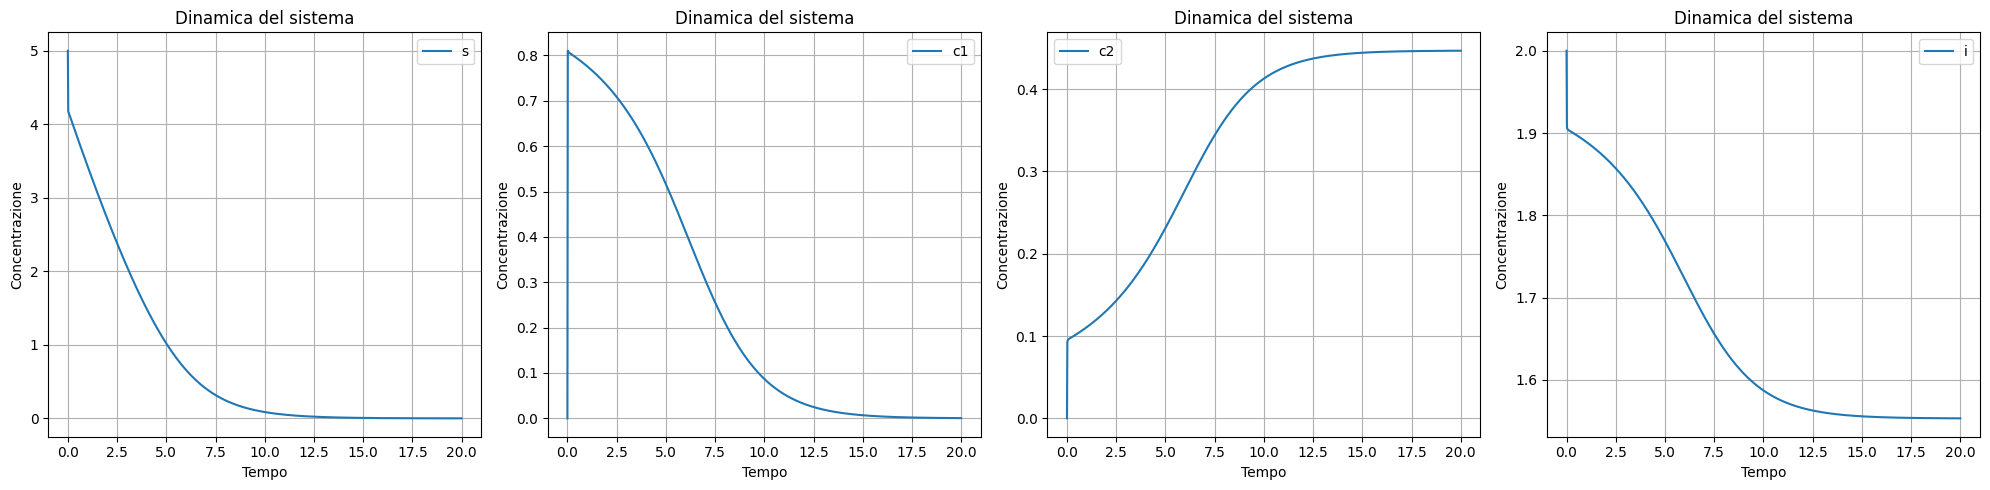

In [78]:
#params 
c1_0 = 0
c2_0 = 0 
s0 = 5 
i0 = 2
e0 = 1


k1, k_1, k2, k3, k_3 = 102, 50, 1, 26, 50

def inibition (y, t ):
    s, i, c1, c2 = y
    dsdt = -k1*s*(e0 - c1 -c2) + k_1*c1
    didt = -k3*i*e0 + k3*c1*i + k3*c2*i + k_3*c2
    dc1dt = k1*s*e0 - k1*c1*s - k1*c2*s - (k_1 + k2)*c1
    dc2dt = k3*i* (e0 - c1 - c2) - k_3*c2
    
    return [dsdt, didt, dc1dt, dc2dt]

y0 = [s0, i0, c1_0, c2_0]
t= np.linspace (0, 20, 1000)

#solve 
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 3 rows, 1 column

solution = odeint (inibition, y0, t )
s = solution[:, 0]
i = solution[:, 1]
c1 = solution[:, 2]
c2 = solution [:, 3]

axes[0].plot(t, s, label="s")
axes[1].plot(t, c1, label="c1")
axes[2].plot(t, c2, label="c2")
axes[3].plot (t, i, label= 'i')


for i in range (4): 
    axes[i].set_xlabel("Tempo")
    axes[i].set_ylabel("Concentrazione")
    axes[i].set_title(f"Dinamica del sistema")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout() 
plt.show()

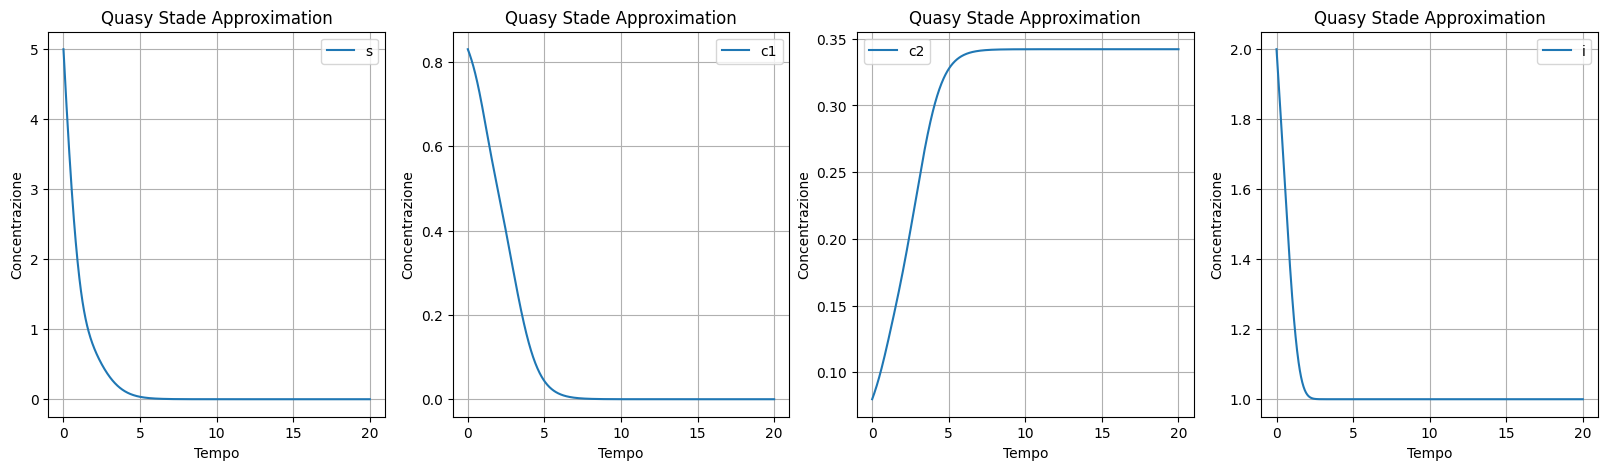

In [79]:
#quasy stade approximation 
#dc1dt= dc2dt = 0
Km =  (k_1 + k2)/ k1
ki = k_3 / k3

v = k2* c1

t = np.linspace(0, 20, 1000)

def quasy_stade_inibition (y, t):
    s, i, = y
    c1 = (e0*s) / ( s+ Km + i*Km / ki)
    c2 = Km*e0*i /(ki*( s+ Km*(i + i/ki)))
    dsdt = -k1*s*e0 + k1*c1*s + k1*c2*s + k_1*c1
    didt = -k3*i*e0 + k3*c1*i + k3*c2*i + k_3*c2
    return [dsdt, didt]

y0 = [s0, i0]
sol_approx = odeint(quasy_stade_inibition, y0, t)
s_app = sol_approx[:, 0]
i_app = sol_approx[:, 1]
c1_app = (e0*s_app) / ( s_app+ Km + i_app*Km / ki)
c2_app = Km*e0*i_app /( ki*( s_app+ Km*(i_app + i_app/ki)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 3 rows, 1 column

axes[0].plot(t, s_app, label="s")
axes[1].plot(t, c1_app, label="c1")
axes[2].plot(t, c2_app, label="c2")
axes[3].plot (t, i_app, label= 'i')

for i in range (4): 
    axes[i].set_xlabel("Tempo")
    axes[i].set_ylabel("Concentrazione")
    axes[i].set_title(f"Quasy Stade Approximation")
    axes[i].legend()
    axes[i].grid(True)

plt.show()

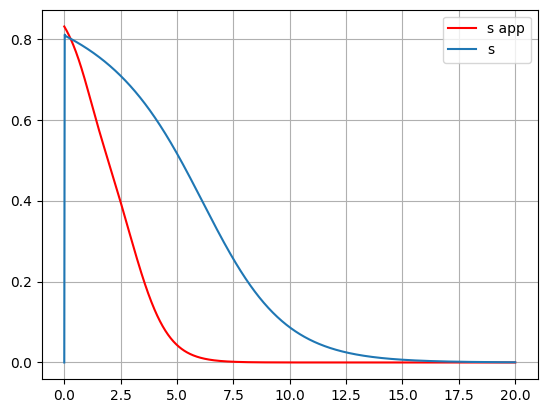

In [80]:
plt.plot(t, c1_app, label="s app", color="r")
plt.plot(t, c1, label="s")
plt.legend()
plt.grid()
#plt.xlim(-0.05, 0.5)
plt.show()

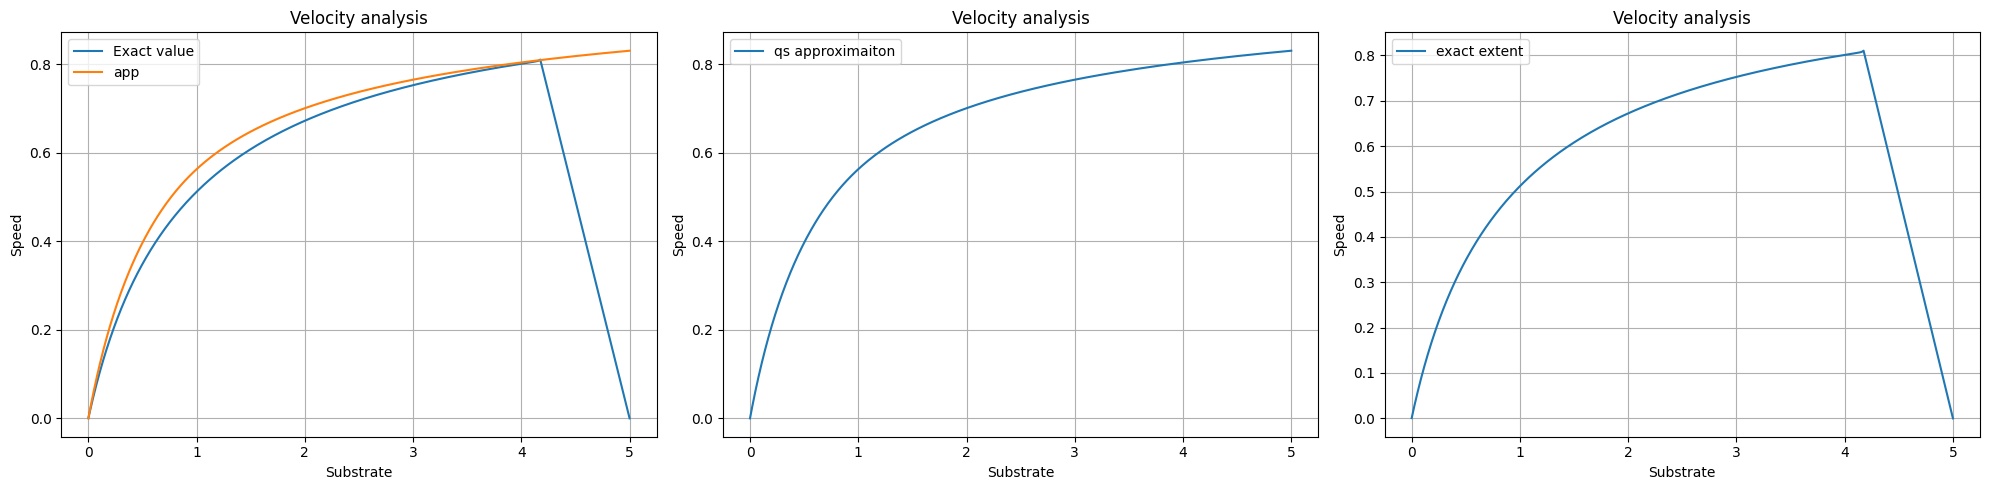

In [81]:
#Velocity analysis 

v = k2*c1
v_app = k2* c1_app
 
mask = (s >= 0) & (s <= 5)
s_lim = s[mask]
v_lim = v[mask]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # 3 rows, 1 column
axes[0].plot(s_lim, v_lim, label = "Exact value")
axes[0].plot(s_app, v_app, label = "app")
axes[1].plot(s_app, v_app, label = "qs approximaiton")
axes[2].plot(s, v, label = "exact extent")

for i in range (3):
    axes[i].set_xlabel("Substrate")
    axes[i].set_ylabel("Speed")
    axes[i].set_title(f"Velocity analysis")
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout() 
plt.show()

C:\Users\bulga\AppData\Local\Temp\ipykernel_12968\1950858860.py:4: RuntimeWarning: divide by zero encountered in divide
  err_C1 = (np.abs(c1 - c1_app) / c1)
C:\Users\bulga\AppData\Local\Temp\ipykernel_12968\1950858860.py:5: RuntimeWarning: divide by zero encountered in divide
  err_C2 = (np.abs(c2 - c2_app) / c2)


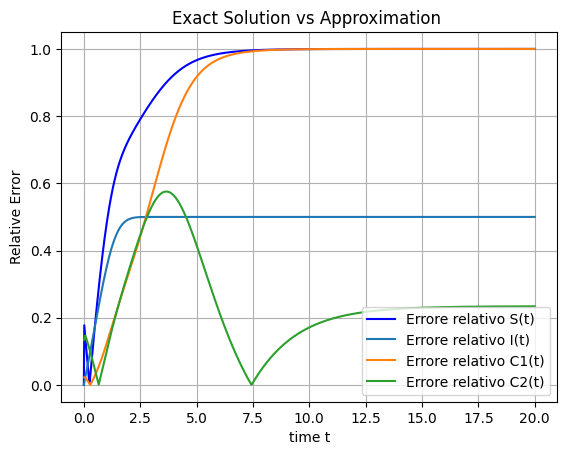

In [82]:
#approximation Error analysis 

err_S = np.abs(s_app - s)/ s
err_C1 = (np.abs(c1 - c1_app) / c1)
err_C2 = (np.abs(c2 - c2_app) / c2)
err_i = (np.abs(i - i_app)/ i)

plt.plot(t, err_S, label='Errore relativo S(t)', color='b')  
plt.plot(t, err_i, label='Errore relativo I(t)')
plt.plot(t, err_C1, label='Errore relativo C1(t)')
plt.plot(t, err_C2, label='Errore relativo C2(t)')

plt.xlabel('time t')
plt.ylabel('Relative Error')
plt.title('Exact Solution vs Approximation ')

plt.legend()
plt.grid(True)
plt.show()

In [83]:
err_i = np.mean(np.abs(i - i_app)/ i)
err_S = np.mean( np.abs(s- s_app)/ s)
#err_C1 = np.mean(np.abs(c1 - c1_app) / c1)
#err_C2 = np.mean(np.abs(c2 - c2_app) / c2)
epsilon =  0.001
err_C1 = np.mean(np.abs(c1 - c1_app) / np.where(np.abs(c1) > epsilon, np.abs(c1), epsilon))
err_C2 = np.mean(np.abs(c2 - c2_app) / np.where(np.abs(c2) > epsilon, np.abs(c2), epsilon))

print ( "err_i", err_i, "errS", err_S, "err_c1:", err_C1, "err_c2:", err_C2)

### ERRORE C1 NO SENSE !!!!

err_i 0.4806948830191362 errS 0.9209235423238998 err_c1: 1.6689333261262884 err_c2: 0.31708039171187685


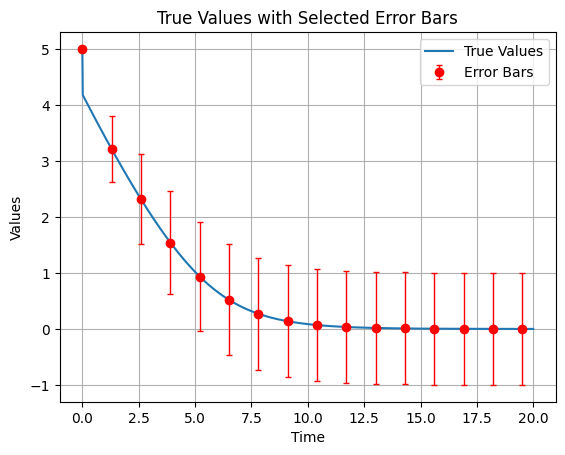

In [84]:
N = 65
t_error = t[::N]
s_error = s[::N]
err_s =  np.abs(s- s_app)/ s
err_s_subset = err_s[::N]

plt.plot(t, s, label='True Values')
plt.errorbar(t_error, s_error, yerr=err_s_subset, fmt='o', color='red', ecolor='red', elinewidth=1, capsize=2, label='Error Bars')

# Labels and title
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('True Values with Selected Error Bars')
plt.legend()
plt.grid(True)